In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("../src")
%load_ext autoreload
%autoreload 2
from data_preprocessing import validate_dataframe, clean_data, encode_categoricals, norm_preprocessor, select_columns, check_data_quality

In [3]:
focus_columns = ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day',
                'app_opens_per_day', 'weekend_screen_time', 'academic_work_impact']
label_column = 'stress_level'

In [4]:
month1 = pd.read_csv('../data/drift/Smartphone_Usage_And_Addiction_Analysis_2000_Rows.csv')
month2 = pd.read_csv('../data/drift/Smartphone_Usage_And_Addiction_Analysis_1900_Rows.csv')

In [5]:
print("Month1 Val: ", validate_dataframe(month1, focus_columns, label_column))
print("Month2 Val: ", validate_dataframe(month2, focus_columns, label_column))

Month1 Val:  True
Month2 Val:  True


In [6]:
month1.info()
month2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           2000 non-null   object 
 1   user_id                  2000 non-null   object 
 2   age                      2000 non-null   int64  
 3   gender                   2000 non-null   object 
 4   daily_screen_time_hours  2000 non-null   float64
 5   social_media_hours       2000 non-null   float64
 6   gaming_hours             2000 non-null   float64
 7   work_study_hours         2000 non-null   float64
 8   sleep_hours              2000 non-null   float64
 9   notifications_per_day    2000 non-null   int64  
 10  app_opens_per_day        2000 non-null   int64  
 11  weekend_screen_time      2000 non-null   float64
 12  stress_level             2000 non-null   object 
 13  academic_work_impact     2000 non-null   object 
 14  addiction_level         

Since we know that the Datasets are clean and no missing data we can just straight into the drifting

Month 1 we are going to add a decent amount of drift since the data seems pretty even. So we are going to shift sleep hours so that more people are sleeping less and social media hours increases.

In [7]:
social_media_max = month1['social_media_hours'].max()
social_media_min = month1['social_media_hours'].min()
print("Social Media Hours Max: ", social_media_max)
print("Social Media Hours Min: ", social_media_min)

Social Media Hours Max:  5.99
Social Media Hours Min:  0.5


In [8]:
def increase_low(hours):
    if hours <= 3:
        return hours + np.random.normal(0.5, 0.15)
    return hours

In [9]:
month1['social_media_hours'] = month1['social_media_hours'].apply(increase_low)
month1["social_media_hours"] = month1["social_media_hours"].clip(social_media_min, social_media_max)

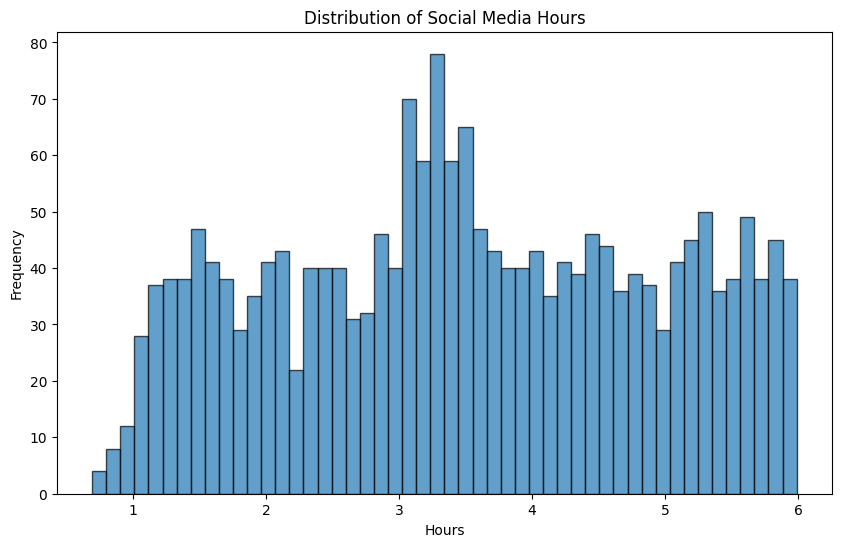

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(month1['social_media_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Social Media Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

In [11]:
sleep_max = month1['sleep_hours'].max()
sleep_min = month1['sleep_hours'].min()
print("Sleep Hours Max: ", sleep_max)
print("Sleep Hours Min: ", sleep_min)

Sleep Hours Max:  9.0
Sleep Hours Min:  4.5


In [12]:
def decrease_high(hours):
    if hours >= 7:
        return hours - np.random.normal(1.0, 0.25)
    return hours

In [13]:
month1['sleep_hours'] = month1['sleep_hours'].apply(decrease_high)
month1["sleep_hours"] = month1["sleep_hours"].clip(sleep_min, sleep_max)

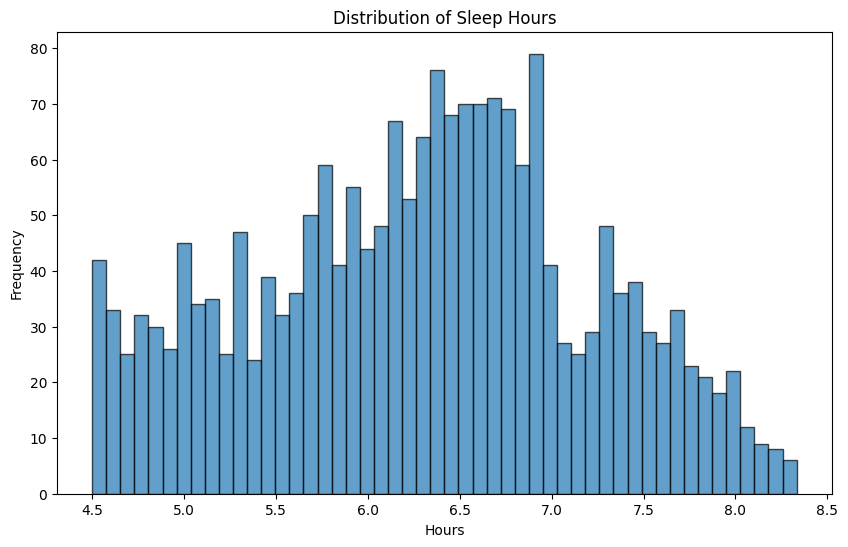

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(month1['sleep_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Sleep Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

Month 2 we are going to increase Social Media hours intensly and increase the number of notifications per day.

In [15]:
social_media_max = month2['social_media_hours'].max()
social_media_min = month2['social_media_hours'].min()
print("Social Media Hours Max: ", social_media_max)
print("Social Media Hours Min: ", social_media_min)

Social Media Hours Max:  6.0
Social Media Hours Min:  0.5


In [16]:
def increase_low_intense(hours):
    if hours <= 3:
        return hours + np.random.normal(2.0, 0.55)
    return hours

In [17]:
month2['social_media_hours'] = month2['social_media_hours'].apply(increase_low_intense)
month2["social_media_hours"] = month2["social_media_hours"].clip(social_media_min, social_media_max)

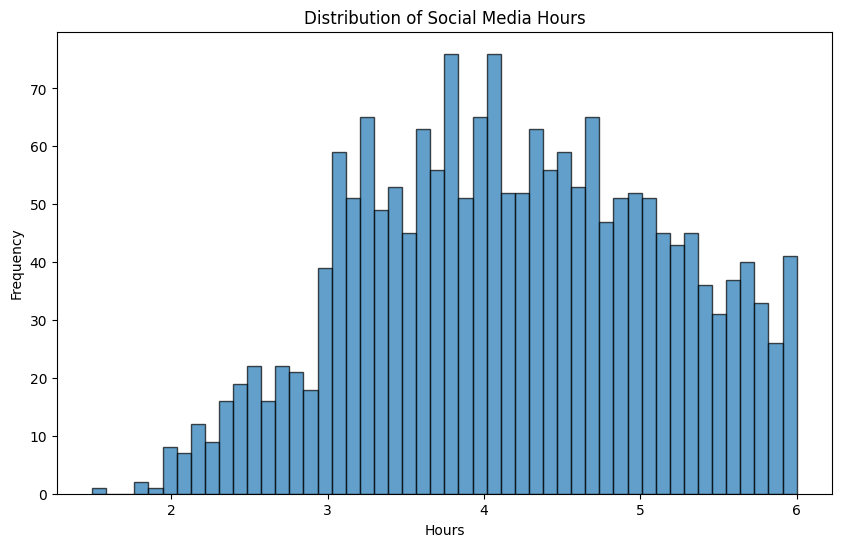

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(month2['social_media_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Social Media Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

In [19]:
notif_max = month2['notifications_per_day'].max()
notif_min = month2['notifications_per_day'].min()
print("Notifications Max: ", notif_max)
print("Notifications Min: ", notif_min)

Notifications Max:  250
Notifications Min:  20


In [20]:
def increase_low_notif(count):
    if count <= 150:
        return count + np.random.normal(40.0, 15.0)
    return count

In [21]:
month2['notifications_per_day'] = month2['notifications_per_day'].apply(increase_low_notif)
month2["notifications_per_day"] = month2["notifications_per_day"].clip(notif_min, notif_max)

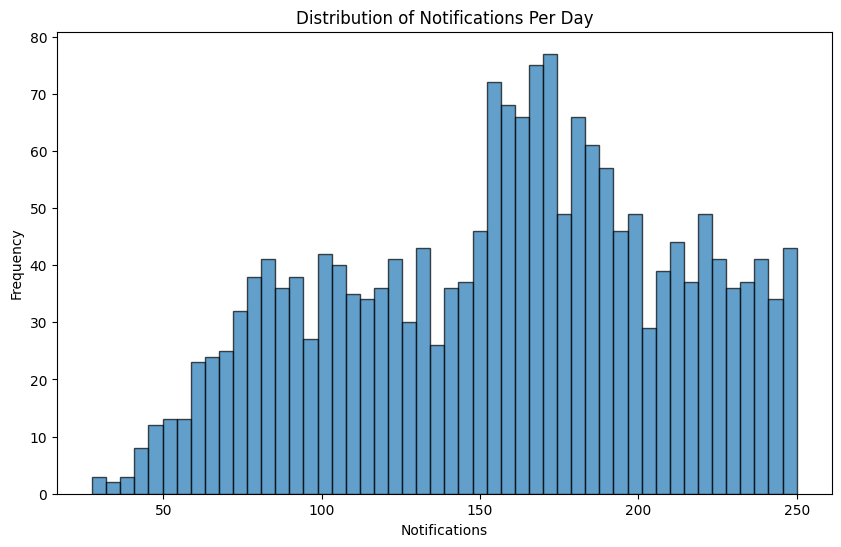

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(month2['notifications_per_day'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Notifications Per Day')
plt.xlabel('Notifications')
plt.ylabel('Frequency')
plt.show()

In [24]:
month1.to_csv("../data/drift/month1_data.csv", index=False)
month2.to_csv("../data/drift/month2_data.csv", index=False)